In [27]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [28]:
X, y = make_circles(n_samples=100, noise=0.1, random_state=1)

In [30]:
df = pd.DataFrame(X, columns=["feature1","feature2"])
df["label"] = y

In [31]:
df.head()

,feature1,feature2,label
0,-0.636405,-0.368702,1
1,-0.244660,-0.736592,1
2,-0.465971,-1.066877,0
3,-0.709998,-0.408419,1
4,0.702322,-0.517301,1


<Axes: xlabel='feature1', ylabel='feature2'>

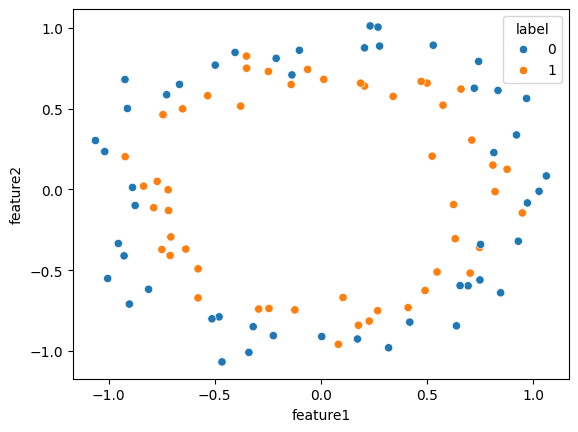

In [34]:
sns.scatterplot(x="feature1",y="feature2",hue="label",data=df)

# OR

# sns.scatterplot(x=X[:,0],y=X[:,1],hue=y)

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

In [41]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

d:\anaconda3\envs\ml_1env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [58]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, verbose=0)

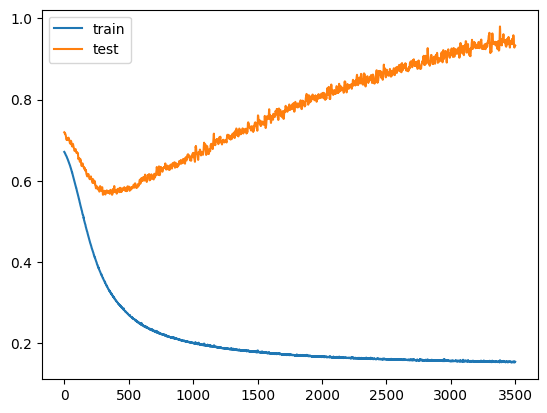

In [59]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 720us/step


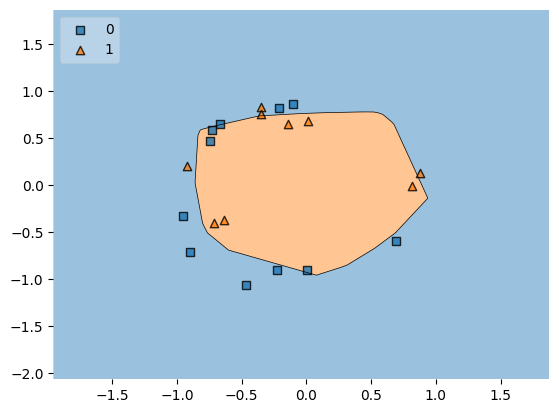

In [60]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()

### Early Stopping

In [88]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

d:\anaconda3\envs\ml_1env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [89]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [90]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=100,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [91]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, callbacks=callback)

Epoch 1/3500


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.4875 - loss: 0.6950 - val_accuracy: 0.4500 - val_loss: 0.7005
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5125 - loss: 0.6931 - val_accuracy: 0.3500 - val_loss: 0.7024
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5500 - loss: 0.6913 - val_accuracy: 0.3500 - val_loss: 0.7025
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5375 - loss: 0.6905 - val_accuracy: 0.4000 - val_loss: 0.7048
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5500 - loss: 0.6893 - val_accuracy: 0.4000 - val_loss: 0.7058
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5625 - loss: 0.6885 - val_accuracy: 0.3000 - val_loss: 0.7071
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5625 - loss: 0.6876 - val_accuracy: 0.2500 - val_loss: 0.7089
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5500 - loss: 0.6869 - val_accuracy: 0.3000 - val_loss: 0.7

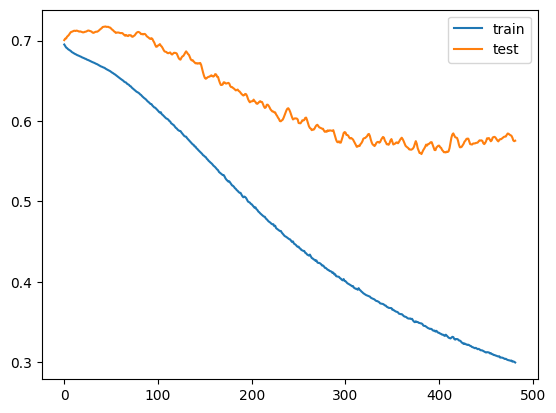

In [92]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 790us/step


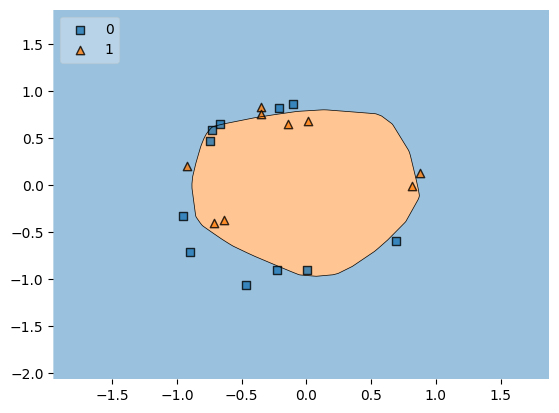

In [93]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()